# ElasticSearch Item Forecast

## Predict on Request

In [53]:
from tensorflow.keras.models import load_model
from elasticsearch import Elasticsearch
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from datetime import timedelta

In [5]:
es = Elasticsearch()

Get all entries for specific item

In [6]:
item_source= []
for date in range (16,23):
    res = es.search(index="queues", body={"query" : {
                                            "bool" : { 
                                              "must" : [
                                                {"match": {
                                                        "name" : "products"}},
                                                {"range": {
                                                        "timestamp":{
                                                            "gte": "2019-12-"+str(date),
                                                            "lte": "2019-12-"+str(date),
                                                            "format": "yyyy-MM-dd"
                                                        }}},
                                                {"regexp" : {
                                                        "items" : ".*3729398496.*"
                                                    }
                                                }
                                                    
                                                  
                                              ]
                                            }
                                          }
                                        }, size=1440) #define size
    i = [elem['_source'] for elem in res['hits']['hits']]
    item_source.extend(i)    

## Build Dataframe

In [9]:
df_es = pd.DataFrame(item_source)

In [10]:
df_es.index = df_es["timestamp"]

In [11]:
df_es.index = pd.to_datetime(df_es.index, format='%Y-%m-%dT%H:%M:%S.%f%z').sort_values()

In [12]:
df_es.drop(columns=['timestamp', 'name', 'tier'], inplace=True)

In [13]:
df_es['items'] = df_es['items'].str.split(" ")

In [14]:
df_es['items'] = [[] if type(x) != list else x for x in df_es['items']]

In [15]:
df_es['diff'] = df_es['size'] - df_es['size'].shift(1)

In [16]:
lists = df_es['items'].tolist()
current = lists[0]
diff_sets = [[]]
diff_sets_rev = [[]]
for next_list in lists[1:]:
    diff_sets.append(sorted(set(current).difference(set(next_list))))
    diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
    current = next_list

In [17]:
df_es['diff_items'] = diff_sets
df_es['diff_items_rev'] = diff_sets_rev
df_es['n_removed'] = df_es['diff_items'].apply(lambda x: len(x))
df_es['n_added'] = df_es['diff_items_rev'].apply(lambda x: len(x))

We assume that we miss the last 500 steps of the item in the queue

In [20]:
df_test = df_es[:-500].copy()

In [21]:
df_test.head()

,querytime,items,size,diff,diff_items,diff_items_rev,n_removed,n_added
timestamp,,,,,,,,
2019-12-20 15:25:32.663834+00:00,612,"[3729398496, 3849987633, 19527465, 4133442579,...",7903,NaN,[],[],0,0
2019-12-20 15:26:04.031366+00:00,604,"[3729398496, 3849987633, 19527465, 4133442579,...",7875,-28.0,"[1091868841, 1118804408, 1510704772, 151657514...",[3682484861],29,1
2019-12-20 15:26:33.412984+00:00,456,"[3729398496, 3849987633, 19527465, 4133442579,...",7878,3.0,[],"[3631956122, 4056733087, 853869716]",0,3
2019-12-20 15:27:03.026404+00:00,329,"[3729398496, 3849987633, 19527465, 4133442579,...",7880,2.0,[],"[1443842319, 705285765]",0,2
2019-12-20 15:27:33.475602+00:00,434,"[3729398496, 3849987633, 19527465, 4133442579,...",7881,1.0,[],[1343176049],0,1


In [22]:
df_test.drop(columns=['querytime', 'items', 'diff', 'diff_items', 'diff_items', 'diff_items_rev'], inplace=True)

In [23]:
df_test.head()

,size,n_removed,n_added
timestamp,,,
2019-12-20 15:25:32.663834+00:00,7903,0,0
2019-12-20 15:26:04.031366+00:00,7875,29,1
2019-12-20 15:26:33.412984+00:00,7878,0,3
2019-12-20 15:27:03.026404+00:00,7880,0,2
2019-12-20 15:27:33.475602+00:00,7881,0,1


In [26]:
df_test['n_steps_in_Q'] = np.arange(len(df_test))

In [27]:
df_test.head()

,size,n_removed,n_added,n_steps_in_Q
timestamp,,,,
2019-12-20 15:25:32.663834+00:00,7903,0,0,0
2019-12-20 15:26:04.031366+00:00,7875,29,1,1
2019-12-20 15:26:33.412984+00:00,7878,0,3,2
2019-12-20 15:27:03.026404+00:00,7880,0,2,3
2019-12-20 15:27:33.475602+00:00,7881,0,1,4


In [28]:
df_test = df_test[['n_steps_in_Q', 'size', 'n_added', 'n_removed']]

In [30]:
df_test_np = np.array(df_test)

In [31]:
df_test_np.shape

(1969, 4)

We reshape our test data, so that it matches with our model

In [32]:
df_test_con = np.concatenate((df_test_np, [[0,0,0,0]]*(6036-df_test_np.shape[0])))

In [33]:
df_test_np.shape

(1969, 4)

In [34]:
df_test_con = df_test_con.reshape(1,6036,4)

In [35]:
df_test_con.shape

(1, 6036, 4)

We use the same scaler as in our pretrained model

In [41]:
scaler_X = pickle.load(open("scaler_X_1w.p", "rb"))
scaler_y = pickle.load(open("scaler_y_1w.p", "rb"))

In [42]:
df_test_sca = scaler_X.transform(df_test_con.reshape(-1, 4)).reshape(df_test_con.shape)

In [43]:
df_test_sca.shape

(1, 6036, 4)

## Load Model

In [44]:
model = load_model("model_items_1w.h5")

In [45]:
new_pred = model.predict(df_test_sca)

## Rescaling

Predictions 

In [46]:
y_pred = scaler_y.inverse_transform(new_pred.reshape(-1, 1)).reshape(new_pred.shape)

1969 is the number of steps in Q of the item, so we just need the value at that point

In [47]:
y_pred[:,1969,:]

array([[772.4748]], dtype=float32)

In [48]:
y_pred_plot = y_pred.reshape(-1,1)

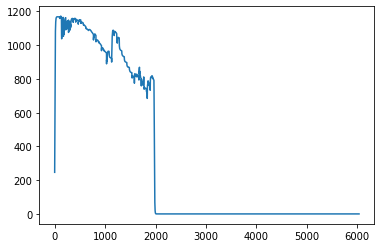

In [51]:
plt.plot(y_pred_plot)

In [52]:
int(y_pred_plot[1969])

772

Predicted timestamp

In [54]:
df_test.index[-1] + timedelta(seconds=30)*int(y_pred_plot[1969])

Timestamp('2019-12-21 14:40:32.464584+0000', tz='UTC')